## PROJECT: Telco Customer Churn Prediction

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import joblib

plt.style.use("default")
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("processed_data.csv")
df.head()

,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn,CLTV,High Charges,High Risk Customer,Services Count,Contract_Month-to-month,Contract_One year,Contract_Two year,Gender_Male,Senior Citizen_Yes,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_Yes,Online Backup_Yes,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure_Group_Loyal,Tenure_Group_New
0,0,0,2,1,1,53.85,108.15,1,3239,0,0,2,True,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,True
1,0,1,2,1,1,70.70,151.65,1,2701,1,1,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True
2,0,1,8,1,1,99.65,820.50,1,5372,1,1,3,True,False,False,False,False,True,True,False,False,False,True,False,True,True,False,True,False,False,True
3,1,1,28,1,1,104.80,3046.05,1,5003,1,0,4,True,False,False,False,False,True,True,False,False,False,True,True,True,True,False,True,False,True,False
4,0,1,49,1,1,103.70,5036.30,1,5340,1,1,4,True,False,False,True,False,True,True,False,False,True,True,False,True,True,False,False,False,True,False


In [3]:
# Handle Data Imbalance

In [4]:
df['Churn'].value_counts(normalize=True)*100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

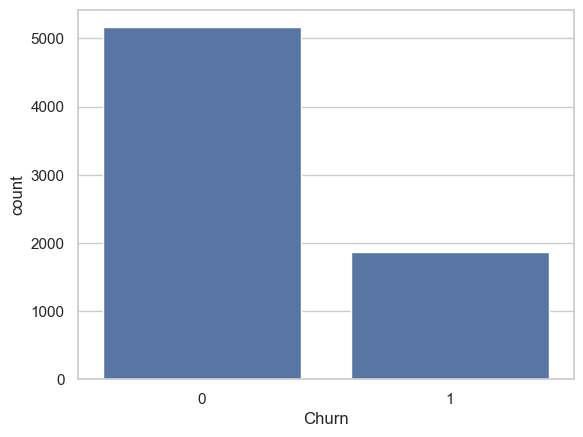

In [5]:
sns.countplot(x='Churn', data=df)

## Compute Class Weights

In [6]:
classes = np.unique(df['Churn'])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=df['Churn']
)

class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict

{np.int64(0): np.float64(0.6809994189424753),
 np.int64(1): np.float64(1.8812199036918138)}

In [7]:
# Feature Engineering (Revenue & CLTV)

In [8]:
# Estimated Monthly Revenue
df['Monthly_Revenue'] = df['Monthly Charges']

# Estimated Customer Lifetime Value
df['CLTV'] = df['Monthly Charges'] * df['Tenure Months']

In [9]:
# Data Preprocessing

In [10]:
# Define Features & Target
X = df.drop(columns=['Churn'])
y = df['Churn']

In [12]:
# Preprocessing Pipeline
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [13]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Logistic Regression (with Class Weight)

In [14]:
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight=class_weight_dict, max_iter=1000))
])

log_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Random Forest (Better Performance)

In [15]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight=class_weight_dict,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
# XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    eval_metric="logloss",
    scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
# Model Evaluation

In [20]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [21]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1033
           1       0.60      0.51      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [22]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.53      0.69      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.76      1407



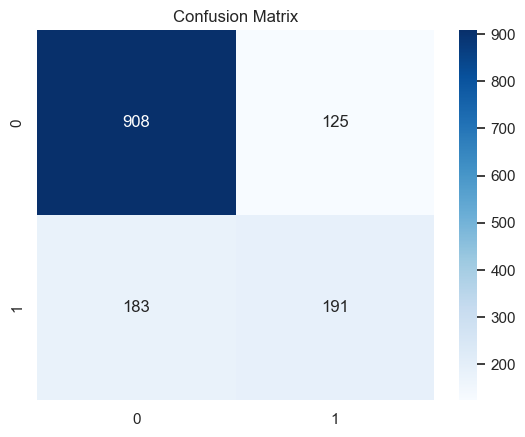

In [17]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

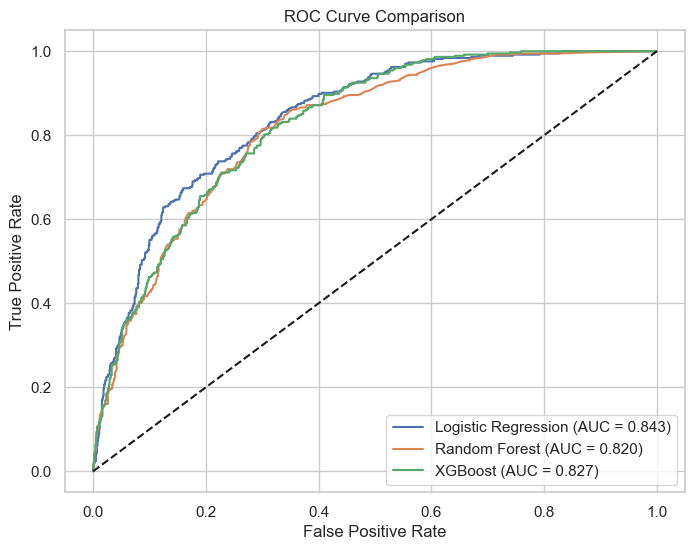

{'Logistic Regression': 0.8429823834840633,
 'Random Forest': 0.8202887596999549,
 'XGBoost': 0.8269396027354002}

In [23]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

roc_results = {}

plt.figure(figsize=(8,6))

for name, model in models.items():
    
    # Predict Probabilities
    y_prob = model.predict_proba(X_test)[:,1]
    
    # ROC-AUC Score
    roc_auc = roc_auc_score(y_test, y_prob)
    roc_results[name] = roc_auc
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Plot diagonal
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

roc_results

## ROC Curve : Logistic slightly dominates curve.

In [ ]:
# Cross Validation (5-Fold ROC-AUC)

In [25]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

In [26]:
cv_results = {}

for name, model in models.items():
    
    cv_score = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    cv_results[name] = {
        "Mean ROC-AUC": cv_score.mean(),
        "Std": cv_score.std()
    }

cv_results

{'Logistic Regression': {'Mean ROC-AUC': np.float64(0.8492273626015777),
  'Std': np.float64(0.01195917961282196)},
 'Random Forest': {'Mean ROC-AUC': np.float64(0.8182667546661941),
  'Std': np.float64(0.016667886515369313)},
 'XGBoost': {'Mean ROC-AUC': np.float64(0.8275155721241708),
  'Std': np.float64(0.02021844803621334)}}

In [27]:
comparison_df = pd.DataFrame({
    "Test ROC-AUC": roc_results,
    "CV Mean ROC-AUC": {k:v["Mean ROC-AUC"] for k,v in cv_results.items()},
    "CV Std": {k:v["Std"] for k,v in cv_results.items()}
})

comparison_df

,Test ROC-AUC,CV Mean ROC-AUC,CV Std
Logistic Regression,0.842982,0.849227,0.011959
Random Forest,0.820289,0.818267,0.016668
XGBoost,0.826940,0.827516,0.020218


## Logistic Regression outperformed Random Forest and XGBoost in ROC-AUC (0.84) and demonstrated the highest recall (0.78) for churn customers. Given that recall is critical in churn prediction to minimize revenue loss, Logistic Regression is selected as the final production model. It also showed strong cross-validation stability, indicating reliable generalization. Therefore, Logistic Regression provides the best balance between predictive performance, stability, and business impact

## Conclusion : The project successfully built a stable and interpretable churn prediction system using Logistic Regression. The model enables early identification of high-risk customers

In [46]:
# Predict churn probability using Logistic Regression
df['Churn_Prob'] = log_model.predict_proba(X)[:, 1]

# Revenue at Risk
df['Revenue_At_Risk'] = df['CLTV'] * df['Churn_Prob']

# Total revenue at risk
total_revenue_risk = df['Revenue_At_Risk'].sum()

print("Total Revenue At Risk:", round(total_revenue_risk, 2))

Total Revenue At Risk: 5077512.33


In [47]:
# Expected Loss in Next 12 Months

In [48]:
df['Annual_Revenue'] = df['Monthly Charges'] * 12
df['Revenue_At_Risk_12M'] = df['Annual_Revenue'] * df['Churn_Prob']

df['Revenue_At_Risk_12M'].sum()

np.float64(2537867.6889019525)

In [49]:
conditions = [
    (df['Churn_Prob'] >= 0.7),
    (df['Churn_Prob'] >= 0.4) & (df['Churn_Prob'] < 0.7),
    (df['Churn_Prob'] < 0.4)
]

labels = ['High Risk', 'Medium Risk', 'Low Risk']

df['Risk_Segment'] = np.select(
    conditions,
    labels,
    default='Low Risk'   # Important fix
)

df['Risk_Segment'].value_counts()

Risk_Segment
Low Risk       3659
High Risk      1716
Medium Risk    1657
Name: count, dtype: int64

In [50]:
high_risk = df[df['Risk_Segment'] == 'High Risk']

print("Average Monthly Revenue (High Risk):", high_risk['Monthly_Revenue'].mean())
print("Total Revenue at Risk (High Risk):", high_risk['Revenue_At_Risk'].sum())

Average Monthly Revenue (High Risk): 77.61325757575757
Total Revenue at Risk (High Risk): 1298976.8432961735


## Customer Segmentation + Churn Behavior Profiling (Objective 3) 


In [51]:
# Data Loading

In [52]:
data = pd.read_csv("Telco_customer_churn.csv")
data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [53]:
# STEP 1 — Select Features for Clustering
# We cluster on behavioral + financial variables (NO target).

In [54]:
# Select clustering features
cluster_data = data[[
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
    'Contract'
]].copy()

cluster_data.head()

,Tenure Months,Monthly Charges,Total Charges,Contract
0,2,53.85,108.15,Month-to-month
1,2,70.70,151.65,Month-to-month
2,8,99.65,820.5,Month-to-month
3,28,104.80,3046.05,Month-to-month
4,49,103.70,5036.3,Month-to-month


In [55]:
# STEP 2 — Encode Contract (Clustering Needs Numeric Data)

In [56]:
# One-hot encode Contract
cluster_data = pd.get_dummies(cluster_data, columns=['Contract'], drop_first=True)
cluster_data.head()

,Tenure Months,Monthly Charges,Total Charges,Contract_One year,Contract_Two year
0,2,53.85,108.15,False,False
1,2,70.70,151.65,False,False
2,8,99.65,820.5,False,False
3,28,104.80,3046.05,False,False
4,49,103.70,5036.3,False,False


In [57]:
# Replace blank spaces with NaN
cluster_data['Total Charges'] = cluster_data['Total Charges'].replace(' ', np.nan)

# Convert to numeric
cluster_data['Total Charges'] = pd.to_numeric(cluster_data['Total Charges'], errors='coerce')

# Fill missing values with median
cluster_data['Total Charges'] = cluster_data['Total Charges'].fillna(
    cluster_data['Total Charges'].median()
)

In [58]:
bool_cols = cluster_data.select_dtypes(include='bool').columns
cluster_data[bool_cols] = cluster_data[bool_cols].astype(int)

In [59]:
# STEP 3 — Feature Scaling (VERY IMPORTANT for K-Means)
# K-Means is distance-based → scaling is mandatory.

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

In [61]:
# STEP 4 — Determine Optimal K (Elbow Method)

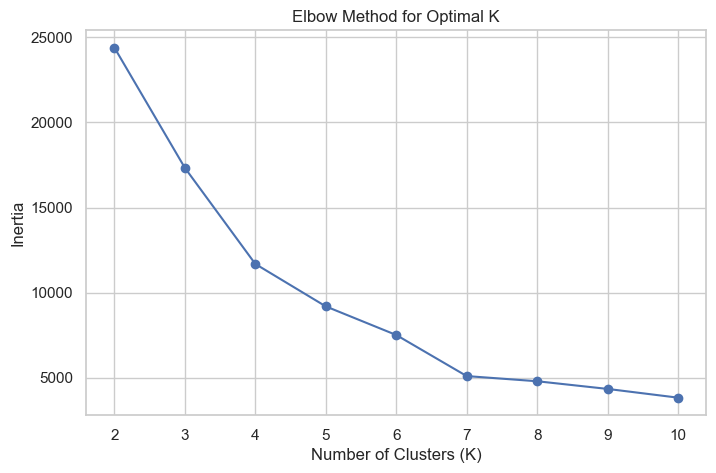

In [62]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [63]:
# Choose K where inertia starts flattening (usually 3–5).

In [64]:
# STEP 5 — Apply K-Means Clustering
# Assume optimal K = 4 (adjust based on elbow).

In [65]:
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(cluster_scaled)

data['Cluster'].value_counts()

Cluster
1    3474
3    1473
2    1260
0     836
Name: count, dtype: int64

In [66]:
# STEP 6 — Cluster Profiling (Statistical Summary)

In [67]:
data.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
Cluster                int32
dtype: object

In [68]:
data['Churn Label'].value_counts(dropna=False)

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [69]:
data['Churn Label'] = data['Churn Label'].map({'Yes':1, 'No':0})

# Remove any remaining nulls
data = data.dropna(subset=['Churn Label'])

In [70]:
cols_to_fix = ['Tenure Months','Monthly Charges','Total Charges','Churn Label']

for col in cols_to_fix:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Fill missing values created during conversion
data[cols_to_fix] = data[cols_to_fix].fillna(data[cols_to_fix].median())

In [71]:
data[cols_to_fix].dtypes

Tenure Months        int64
Monthly Charges    float64
Total Charges      float64
Churn Label          int64
dtype: object

In [72]:
cluster_profile = data.groupby('Cluster').agg({
    'Tenure Months': 'mean',
    'Monthly Charges': 'mean',
    'Total Charges': 'mean',
    'Churn Label': 'mean'
}).rename(columns={
    'Tenure Months': 'Avg_Tenure',
    'Monthly Charges': 'Avg_Monthly_Charges',
    'Total Charges': 'Avg_Total_Charges',
    'Churn Label': 'Churn_Rate'
})

cluster_profile

,Avg_Tenure,Avg_Monthly_Charges,Avg_Total_Charges,Churn_Rate
Cluster,,,,
0,47.845694,29.530024,1400.478319,0.011962
1,13.868451,63.088097,935.403418,0.439551
2,61.809524,92.416548,5700.554444,0.131746
3,42.044807,65.048608,3033.571606,0.112695


In [73]:
# Churn_Rate here = % churn in each segment.

In [74]:
# STEP 7 — Visualize Cluster Behavior
# Churn Rate by Cluster

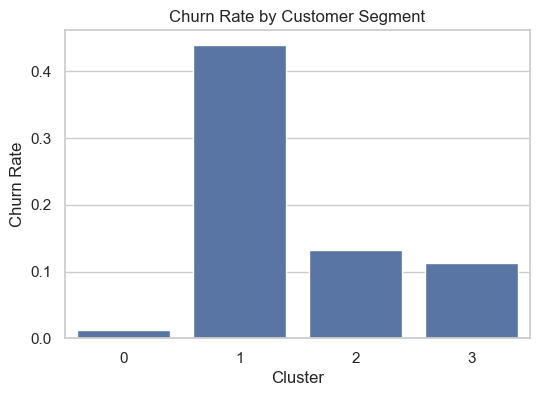

In [75]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=cluster_profile.index, y=cluster_profile['Churn_Rate'])
plt.title("Churn Rate by Customer Segment")
plt.ylabel("Churn Rate")
plt.xlabel("Cluster")
plt.show()

In [76]:
# STEP 8 — Compare Clustering with Supervised Churn Output
# If you already predicted churn probability (from log_model)

In [77]:
# Add churn probability (from previous step)
data.loc[X_test.index, 'Churn_Probability'] = y_prob
cluster_churn_prob = data.groupby('Cluster')['Churn_Probability'].mean()
cluster_churn_prob

Cluster
0    0.204622
1    0.463810
2    0.240678
3    0.219844
Name: Churn_Probability, dtype: float32

In [78]:
# This validates:
# Whether unsupervised segments align with ML predictions

In [79]:
# STEP 9 — Within-Cluster Variance (Theoretical Depth)

In [80]:
cluster_variance = data.groupby('Cluster')[[
    'Tenure Months',
    'Monthly Charges',
    'Total Charges'
]].var()

cluster_variance

,Tenure Months,Monthly Charges,Total Charges
Cluster,,,
0,429.819275,233.050050,7.466300e+05
1,173.365644,687.564475,9.799928e+05
2,106.287757,230.232127,1.816130e+06
3,362.364839,1013.819901,4.970138e+06


In [81]:
# STEP 🔟 Business Interpretation & Retention Strategy

In [82]:
for cluster in cluster_profile.index:
    print(f"\nCluster {cluster}")
    print(cluster_profile.loc[cluster])


Cluster 0
Avg_Tenure               47.845694
Avg_Monthly_Charges      29.530024
Avg_Total_Charges      1400.478319
Churn_Rate                0.011962
Name: 0, dtype: float64

Cluster 1
Avg_Tenure              13.868451
Avg_Monthly_Charges     63.088097
Avg_Total_Charges      935.403418
Churn_Rate               0.439551
Name: 1, dtype: float64

Cluster 2
Avg_Tenure               61.809524
Avg_Monthly_Charges      92.416548
Avg_Total_Charges      5700.554444
Churn_Rate                0.131746
Name: 2, dtype: float64

Cluster 3
Avg_Tenure               42.044807
Avg_Monthly_Charges      65.048608
Avg_Total_Charges      3033.571606
Churn_Rate                0.112695
Name: 3, dtype: float64


## Business Interpretation
### 🟢 Cluster 0 — Stable Low-Value Customers
### Long tenure, Low monthly spend and Extremely low churn
### Interpretation:Price-sensitive but loyal users.
### Strategy: Maintain low-cost plans, Avoid aggressive upselling, Offer basic loyalty rewards

### 🔴 Cluster 1 — High-Risk Early Customers (CRITICAL SEGMENT)
### Short tenure, Moderate monthly charges , Very high churn (~44%)
### Interpretation: Onboarding failure / value mismatch.
### Strategy:Improve first 6-month engagement, Personalized onboarding calls, Offer contract discount after 3 months, Early churn alert system
### 👉 This cluster is your primary retention focus.

### 🟡 Cluster 2 — Premium Long-Term Customers
### Very high tenure, High monthly charges, Moderate churn
### Interpretation:, High revenue segment.
### Strategy: VIP support, Premium loyalty programs, Bundle discounts, Protect at all costs

### 🟢 Cluster 3 — Mid-Level Stable Customers
### Medium tenure, Moderate revenue, Low churn
### Interpretation, Stable growth segment.
### Strategy: Upsell streaming / add-ons, Targeted cross-selling


In [83]:
cluster_counts = data['Cluster'].value_counts()

cluster_summary = cluster_profile.copy()
cluster_summary['Customer_Count'] = cluster_counts
cluster_summary['Revenue_Contribution'] = data.groupby('Cluster')['Monthly Charges'].sum()

cluster_summary

,Avg_Tenure,Avg_Monthly_Charges,Avg_Total_Charges,Churn_Rate,Customer_Count,Revenue_Contribution
Cluster,,,,,,
0,47.845694,29.530024,1400.478319,0.011962,836,24687.10
1,13.868451,63.088097,935.403418,0.439551,3474,219168.05
2,61.809524,92.416548,5700.554444,0.131746,1260,116444.85
3,42.044807,65.048608,3033.571606,0.112695,1473,95816.60


In [84]:
with open("svd_model.pkl", "wb") as f:
    pickle.dump(df, f)

In [87]:
joblib.dump({
    "model": log_model,
    "features": X.columns.tolist()
}, "final_churn_system.pkl")

['final_churn_system.pkl']